# Quantum Volunteer's Dilemma — Figure Reproduction

This notebook reproduces all figures from the paper:

> **Experimental Implementation of the Quantum Volunteer's Dilemma on NISQ Hardware:
> Noise Analysis and Digital Twin Validation**

Data is loaded directly from the public repository. No local files required.

**Repository:** https://github.com/GermanDarDiaz/Quantum-Volunteer-s-Dilemma

**Figures produced:**
- Fig. 1 — Target-state fidelity across all four optimization levels (raw and corrected)
- Fig. 2 — Digital Twin vs. QPU fidelity comparison (L2)
- Fig. 3 — Expected payoffs: target-state contribution and global average (L2)
- Fig. 4 — Hamming distance distribution heatmap (L2)

In [1]:
# ── Dependencies ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import requests
import json

print("Dependencies loaded.")

Dependencies loaded.


## 1. Load data from repository

In [2]:
# ── Load processed results from public repository ─────────────────────────────
REPO_RAW = "https://raw.githubusercontent.com/GermanDarDiaz/Quantum-Volunteer-s-Dilemma/main"
DATA_URL = f"{REPO_RAW}/experiments/figures_data.json"

response = requests.get(DATA_URL)
response.raise_for_status()
d = response.json()

print(f"Data loaded successfully. Player counts: {d['players']}")

Data loaded successfully. Player counts: [2, 3, 4, 5, 6, 7, 8, 9]


In [6]:
# ── Unpack base variables ──────────────────────────────────────────────────────
Players   = d["players"]
Theorist  = d["benchmarks"]["theorist"]
Classical = d["benchmarks"]["classical"]

# All four optimization levels — fidelity
levels = ["L0", "L1", "L2", "L3"]
Mean_Fidelity      = {l: np.array(d["fidelity_all_levels"][l]["fidelity"]["raw"]["mean"])      for l in levels}
ic95_Fidelity      = {l: np.array(d["fidelity_all_levels"][l]["fidelity"]["raw"]["ic95"])      for l in levels}
Mean_Fidelity_corr = {l: np.array(d["fidelity_all_levels"][l]["fidelity"]["corrected"]["mean"]) for l in levels}
ic95_Fidelity_corr = {l: np.array(d["fidelity_all_levels"][l]["fidelity"]["corrected"]["ic95"]) for l in levels}

# L2 — Digital Twin fidelity
Mean_Fidelity_sim = np.array(d["fidelity_all_levels"]["L2"]["fidelity"]["digital_twin"]["mean"])
ic95_Fidelity_sim = np.array(d["fidelity_all_levels"]["L2"]["fidelity"]["digital_twin"]["ic95"])

# L2 — Target-state weighted payoff contribution
Mean_CPayoff     = np.array(d["fidelity_all_levels"]["L2"]["target_state_payoff"]["raw"]["mean"])
Mean_CPayoff_mit = np.array(d["fidelity_all_levels"]["L2"]["target_state_payoff"]["corrected"]["mean"])

# L2 — Global average payoff
Mean_Global_Payoff      = np.array(d["fidelity_all_levels"]["L2"]["global_payoff"]["raw"]["mean"])
ic95_Global_Payoff      = np.array(d["fidelity_all_levels"]["L2"]["global_payoff"]["raw"]["ic95"])
Mean_Global_Payoff_corr = np.array(d["fidelity_all_levels"]["L2"]["global_payoff"]["corrected"]["mean"])
ic95_Global_Payoff_corr = np.array(d["fidelity_all_levels"]["L2"]["global_payoff"]["corrected"]["ic95"])
Mean_Global_Payoff_sim  = np.array(d["fidelity_all_levels"]["L2"]["global_payoff"]["digital_twin"]["mean"])
ic95_Global_Payoff_sim  = np.array(d["fidelity_all_levels"]["L2"]["global_payoff"]["digital_twin"]["ic95"])

# Hamming distance data
hamming_data = {int(k): v for k, v in d["fidelity_all_levels"]["L2"]["hamming"].items()}

# ── Derived quantities (analytically from fidelity CIs) ───────────────────────
N_arr = np.array(Players)
scale = 2.0 - 1.0 / N_arr   # (b - c/N) with b=2, c=1

ic95_CPayoff     = scale * ic95_Fidelity["L2"]
ic95_CPayoff_mit = scale * ic95_Fidelity_corr["L2"]

Mean_CPayoff_sim = Mean_Fidelity_sim * scale
ic95_CPayoff_sim = ic95_Fidelity_sim * scale

print("All variables unpacked and derived quantities computed.")

All variables unpacked and derived quantities computed.


## Fig. 1 — Target-state fidelity across all optimization levels

Fig. 1 saved.


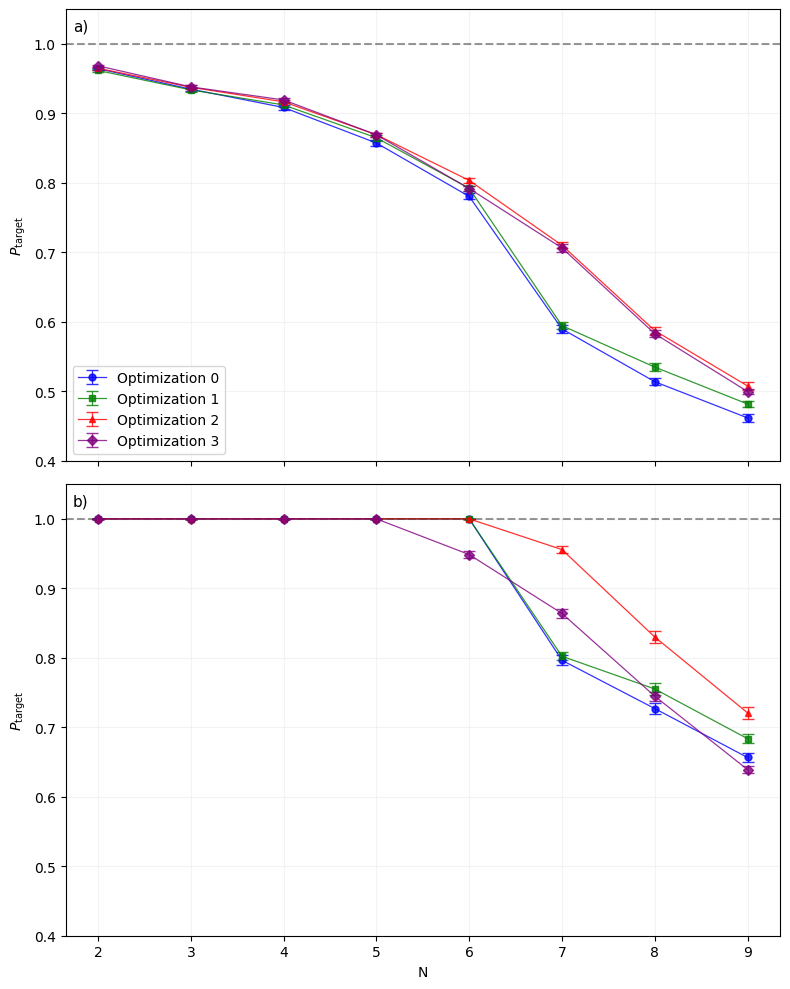

In [7]:
colors  = {"L0": "blue", "L1": "green", "L2": "red", "L3": "purple"}
markers = {"L0": "o",    "L1": "s",     "L2": "^",   "L3": "D"}

fig1, ax1 = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

for l in levels:
    ax1[0].errorbar(
        Players, Mean_Fidelity[l], yerr=ic95_Fidelity[l],
        marker=markers[l], linewidth=0.9, alpha=0.8, markersize=5,
        color=colors[l], ecolor=colors[l], capsize=4,
        label=f"Optimization {l[1:]}"
    )
    ax1[1].errorbar(
        Players, Mean_Fidelity_corr[l], yerr=ic95_Fidelity_corr[l],
        marker=markers[l], linewidth=0.9, alpha=0.8, markersize=5,
        color=colors[l], ecolor=colors[l], capsize=4
    )

for ax in ax1:
    ax.axhline(y=1, linestyle='--', color='black', alpha=0.4)
    ax.set_ylabel(r'$P_{\text{target}}$')
    ax.set_ylim(0.4, 1.05)
    ax.grid(True, alpha=0.15)

ax1[1].set_xlabel('N')
ax1[0].legend()

ax1[0].text(0.01, 0.98, "a)", transform=ax1[0].transAxes, fontsize=11, va='top')
ax1[1].text(0.01, 0.98, "b)", transform=ax1[1].transAxes, fontsize=11, va='top')

fig1.tight_layout()
fig1.savefig('fig1_fidelity_all_levels.png', dpi=600, bbox_inches='tight')
fig1.show()
print("Fig. 1 saved.")

## Fig. 2 — Digital Twin vs. QPU fidelity comparison (L2)

Fig. 2 saved.


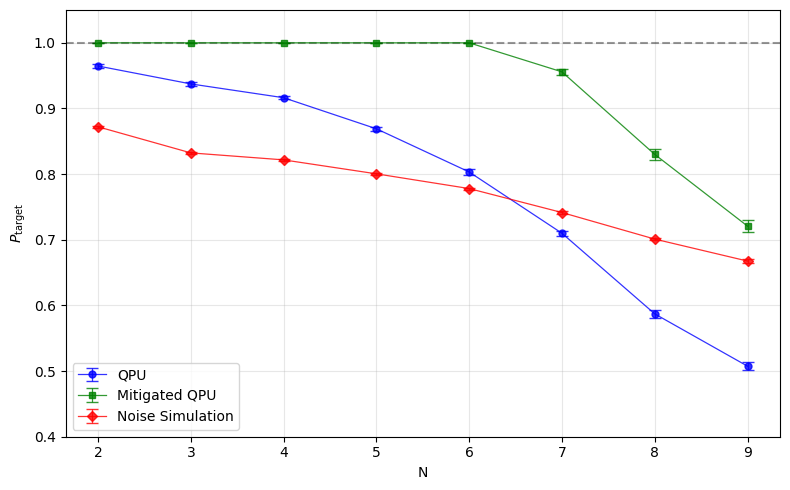

In [8]:
fig2, ax2 = plt.subplots(figsize=(8, 5))

ax2.errorbar(Players, Mean_Fidelity["L2"],      yerr=ic95_Fidelity["L2"],
             marker='o', linewidth=0.9, alpha=0.8, markersize=5,
             color='blue',  ecolor='blue',  capsize=4, label="QPU")
ax2.errorbar(Players, Mean_Fidelity_corr["L2"], yerr=ic95_Fidelity_corr["L2"],
             marker='s', linewidth=0.9, alpha=0.8, markersize=5,
             color='green', ecolor='green', capsize=4, label="Mitigated QPU")
ax2.errorbar(Players, Mean_Fidelity_sim,         yerr=ic95_Fidelity_sim,
             marker='D', linewidth=0.9, alpha=0.8, markersize=5,
             color='red',   ecolor='red',   capsize=4, label="Noise Simulation")

ax2.axhline(y=1, linestyle='--', color='black', alpha=0.4)
ax2.set_ylim(0.4, 1.05)
ax2.set_xlabel('N')
ax2.set_ylabel(r'$P_{\text{target}}$')
ax2.legend()
ax2.grid(True, alpha=0.3)

fig2.tight_layout()
fig2.savefig('fig2_dt_vs_qpu_fidelity.png', dpi=600, bbox_inches='tight')
fig2.show()
print("Fig. 2 saved.")

## Fig. 3 — Expected payoffs (L2)

Fig. 3 saved.


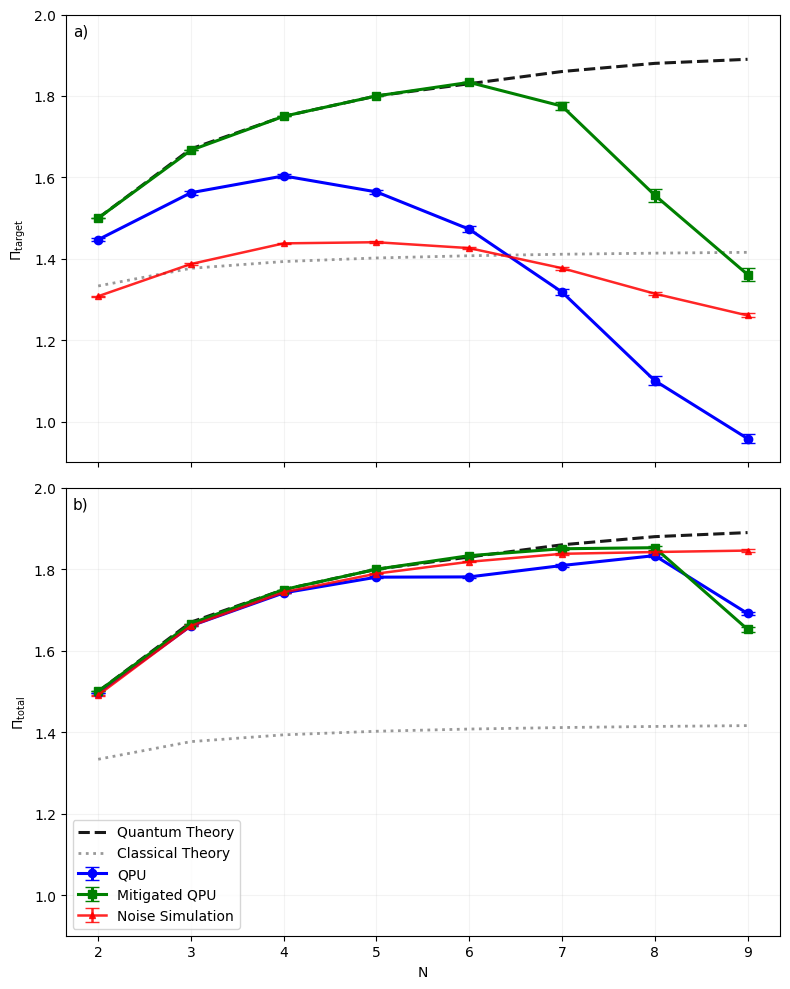

In [9]:
fig3, ax3 = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

# Panel (a) — Target-state weighted payoff contribution
ax3[0].plot(Players, Theorist, linestyle='--', linewidth=2.2, alpha=0.9, color='black')
ax3[0].errorbar(Players, Mean_CPayoff,     yerr=ic95_CPayoff,
                marker='o', linewidth=2.2, alpha=1, markersize=6,
                color='blue',  ecolor='blue',  capsize=5)
ax3[0].errorbar(Players, Mean_CPayoff_mit, yerr=ic95_CPayoff_mit,
                marker='s', linewidth=2.2, alpha=1, markersize=6,
                color='green', ecolor='green', capsize=5)
ax3[0].errorbar(Players, Mean_CPayoff_sim, yerr=ic95_CPayoff_sim,
                marker='^', linewidth=1.8, alpha=0.85, markersize=5,
                color='red',   ecolor='red',   capsize=5)
ax3[0].plot(Players, Classical, linestyle=':', linewidth=2, alpha=0.8, color='gray')
ax3[0].set_ylabel(r"$\Pi_{\mathrm{target}}$")
ax3[0].set_ylim(0.9, 2.0)
ax3[0].grid(True, alpha=0.15)

# Panel (b) — Global average payoff
ax3[1].plot(Players, Theorist, linestyle='--', linewidth=2.2, alpha=0.9, color='black',
            label="Quantum Theory")
ax3[1].errorbar(Players, Mean_Global_Payoff,      yerr=ic95_Global_Payoff,
                marker='o', linewidth=2.2, alpha=1, markersize=6,
                color='blue',  ecolor='blue',  capsize=5, label="QPU")
ax3[1].errorbar(Players, Mean_Global_Payoff_corr, yerr=ic95_Global_Payoff_corr,
                marker='s', linewidth=2.2, alpha=1, markersize=6,
                color='green', ecolor='green', capsize=5, label="Mitigated QPU")
ax3[1].errorbar(Players, Mean_Global_Payoff_sim,  yerr=ic95_Global_Payoff_sim,
                marker='^', linewidth=1.8, alpha=0.85, markersize=5,
                color='red',   ecolor='red',   capsize=5, label="Noise Simulation")
ax3[1].plot(Players, Classical, linestyle=':', linewidth=2, alpha=0.8, color='gray',
            label="Classical Theory")
ax3[1].set_xlabel('N')
ax3[1].set_ylabel(r"$\Pi_{\mathrm{total}}$")
ax3[1].set_ylim(0.9, 2.0)
ax3[1].legend()
ax3[1].grid(True, alpha=0.15)

ax3[0].text(0.01, 0.98, "a)", transform=ax3[0].transAxes, fontsize=11, va='top')
ax3[1].text(0.01, 0.98, "b)", transform=ax3[1].transAxes, fontsize=11, va='top')

fig3.tight_layout()
fig3.savefig('fig3_payoff_comparison.png', dpi=300, bbox_inches='tight')
fig3.show()
print("Fig. 3 saved.")

## Fig. 4 — Hamming distance distribution heatmap (L2)

Fig. 4 saved.


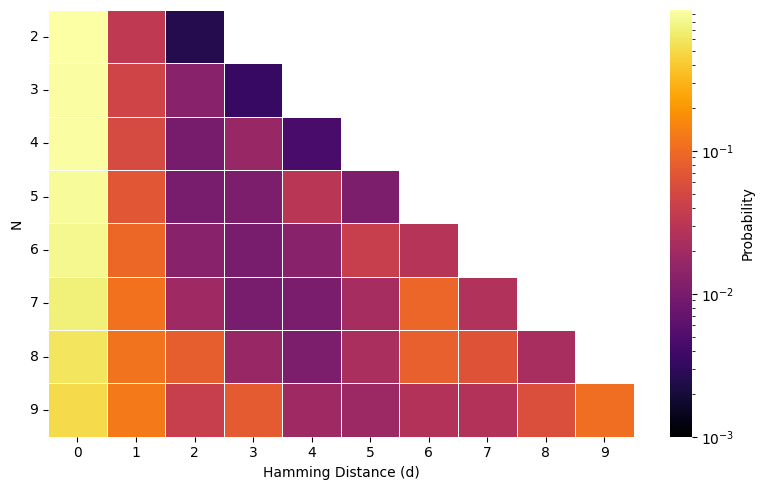

In [10]:
players_sorted = sorted(hamming_data.keys())
max_distance   = max(players_sorted)

matrix = np.full((len(players_sorted), max_distance + 1), np.nan)
for i, N in enumerate(players_sorted):
    probs = hamming_data[N]
    matrix[i, :len(probs)] = probs

fig4, ax4 = plt.subplots(figsize=(8, 5))
mask = np.isnan(matrix)

sns.heatmap(
    matrix,
    mask=mask,
    cmap="inferno",
    norm=LogNorm(vmin=0.001, vmax=np.nanmax(matrix)),
    linewidths=0.5,
    cbar_kws={'label': 'Probability'},
    ax=ax4
)

ax4.set_xlabel("Hamming Distance (d)")
ax4.set_ylabel("N")
ax4.set_xticks(
    ticks=np.arange(max_distance + 1) + 0.5,
    labels=np.arange(max_distance + 1)
)
ax4.set_yticks(
    ticks=np.arange(len(players_sorted)) + 0.5,
    labels=players_sorted,
    rotation=0
)

fig4.tight_layout()
fig4.savefig('fig4_hamming_heatmap.png', dpi=300, bbox_inches='tight')
fig4.show()
print("Fig. 4 saved.")